# Package

In [1]:
# ============================================================
# 1) Core Python & Paths
# ============================================================
import sys
from pathlib import Path
from tempfile import TemporaryDirectory
from dateutil.relativedelta import relativedelta

# Project root (notebook dans /notebooks)
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

# ============================================================
# 2) Data & Utils (Feast + custom utils)
# ============================================================
import pandas as pd
import numpy as np

from utils import load_wide_from_feast, build_unrate_exog_dataset
from experiment_utils import to_wide_from_oos, make_mae_dm_pivot

# ============================================================
# 3) Forecasting (MLForecast + Models)
# ============================================================
from mlforecast import MLForecast
from mlforecast.utils import PredictionIntervals
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# ============================================================
# 4) Evaluation & Statistical Tests
# ============================================================
from scipy.stats import ttest_rel
from statsmodels.stats.contingency_tables import mcnemar

# ============================================================
# 5) Visualization
# ============================================================
from utilsforecast.plotting import plot_series
from IPython.display import IFrame, display

# ============================================================
# 6) Experiment Tracking (MLflow)
# ============================================================
import mlflow
from mlflow.tracking import MlflowClient

# Data Load

In [2]:
series_ids = [
    "BUSLOANS","CPIAUCSL","DPCERA3M086SBEA","INDPRO",
    "M2SL","OILPRICEX","RPI","SP500","TB3MS","UNRATE","USREC",
]

START = "1960-01-01"
END   = "2025-08-01"

In [3]:
# 1) WIDE dataset (tu veux l'appeler df)
df = load_wide_from_feast(
    "stationary_value:value",
    series_ids,
    start=START,
    end=END
)

# 2) Convert WIDE -> LONG (obligatoire pour build_unrate_exog_dataset)
df_stationary = (
    df.reset_index()
      .melt(id_vars="date", var_name="series_id", value_name="value")
)

# 3) Build target + exog + MLForecast format
df_model, ts_lr, exog_cols = build_unrate_exog_dataset(df_stationary)

print("df (wide) shape:", df.shape)
print("df_stationary (long) shape:", df_stationary.shape)
print("df_model shape:", df_model.shape)
print("ts_lr shape:", ts_lr.shape)
print("Exog cols:", exog_cols)

Using date as the event timestamp. To specify a column explicitly, please name it event_timestamp.
df (wide) shape: (788, 11)
df_stationary (long) shape: (8668, 3)
df_model shape: (788, 12)
ts_lr shape: (788, 13)
Exog cols: ['BUSLOANS', 'CPIAUCSL', 'DPCERA3M086SBEA', 'INDPRO', 'M2SL', 'OILPRICEX', 'RPI', 'SP500', 'TB3MS', 'USREC']


d:\Portofolio Data science\Time Series\Explainable_AI_Forecast_and_explain_the_Unemployment_of_USA\3_notebook\ML Experiment\utils.py:171: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("M")


# Model Setting

In [4]:
from mlforecast import MLForecast
from lightgbm import LGBMRegressor

MLF_MODELS = {
    "LGBM_EXOG_ONLY": lambda freq, **params: MLForecast(
        models={"LGBM": LGBMRegressor(**params)},
        freq=freq,
        lags=[],               # EXOG-ONLY
        date_features=[],
    )
}

# Backtesting 

In [5]:
import numpy as np
import pandas as pd
from dateutil.relativedelta import relativedelta
from sklearn.model_selection import ParameterSampler
from sklearn.metrics import mean_absolute_error
from mlforecast.utils import PredictionIntervals

# ============================================================
# Helpers dates / fenêtres
# ============================================================
def _ensure_ms(x):
    x = pd.Timestamp(x)
    return x.to_period("M").to_timestamp(how="start").normalize()

def _n_windows_monthly(ds_start, ds_end):
    return (ds_end.year - ds_start.year) * 12 + (ds_end.month - ds_start.month) + 1

def _slice_cv_block(ts, cutoff_start, n_windows, h):
    cutoff_end = cutoff_start + relativedelta(months=n_windows - 1)
    ds_end = cutoff_end + relativedelta(months=h)
    return ts[ts["ds"] <= ds_end].copy(), cutoff_end, ds_end

# ============================================================
# Tuning (random search) — param_grid fourni depuis le RUN
# ============================================================
def _tune_lgbm_on_train(
    ts_train,
    *,
    freq,
    h,
    tune_cv_windows,      # mini-CV pour le tuning (ex: 6)
    levels,
    param_grid,           # fourni depuis le RUN
    n_iter=100,           # fourni depuis le RUN
    min_train_n=None,
    seed=0,
    use_conformal_in_tune=False,  # recommandé False (beaucoup + rapide)
):
    """
    Tuning LightGBM sur train via mini Nixtla cross_validation (MAE).
    Renvoie (best_params, best_mae).
    """
    if min_train_n is not None and len(ts_train) < int(min_train_n):
        return None, np.nan

    best_params = None
    best_mae = np.inf

    # (optionnel) Conformal pendant le tuning (souvent inutile et coûteux)
    if use_conformal_in_tune:
        pi_tune = PredictionIntervals(h=h, n_windows=tune_cv_windows, method="conformal_distribution")
    else:
        pi_tune = None

    # ✅ Random search: n_iter essais au lieu de tout explorer
    for params in ParameterSampler(param_grid, n_iter=int(n_iter), random_state=seed):
        params = dict(params)

        # Defaults LGBM (stabilité)
        params.setdefault("random_state", seed)
        params.setdefault("verbosity", -1)
        params.setdefault("objective", "regression")
        params.setdefault("metric", "mae")
        params.setdefault("n_jobs", -1)
        params.setdefault("boosting_type", "gbdt")

        mlf = MLF_MODELS["LGBM_EXOG_ONLY"](freq, **params)

        cv = mlf.cross_validation(
            df=ts_train,
            h=h,
            step_size=1,
            n_windows=int(tune_cv_windows),
            prediction_intervals=pi_tune,            # None si use_conformal_in_tune=False
            level=list(levels) if pi_tune is not None else None,
            fitted=False,
            static_features=[],
            dropna=True,
        )

        mae = mean_absolute_error(cv["y"], cv["LGBM"])
        if mae < best_mae:
            best_mae = mae
            best_params = params

    return best_params, float(best_mae)

# ============================================================
# Backtesting mensuel (step=1), tuning tous les 36 mois
# param_grid + n_iter passés depuis le RUN
# ============================================================
def run_backtesting_h12_monthly_tune_every_36m_lgbm(
    ts,
    *,
    freq,
    h=12,
    exp_start="1990-01-01",
    exp_end="2025-08-01",
    step_size=1,
    pi_windows=24,
    levels=[95],
    tune_every_months=36,
    # tuning controls (depuis RUN)
    param_grid=None,
    tune_n_iter=100,
    tune_cv_windows=6,              # mini-CV pour tuning
    min_train_n=None,
    seed=0,
    use_conformal_in_tune=False,    # recommandé False
):
    if param_grid is None:
        raise ValueError("param_grid doit être fourni depuis le RUN (pas de grille par défaut ici).")

    ts = ts.copy()

    # dates MS
    ts["ds"] = (
        pd.to_datetime(ts["ds"], errors="coerce")
          .dt.to_period("M")
          .dt.to_timestamp(how="start")
          .dt.normalize()
    )
    if ts["ds"].isna().any():
        bad = ts[ts["ds"].isna()].head()
        raise ValueError(f"Dates 'ds' invalides après parsing. Exemples:\n{bad}")

    exp_start = _ensure_ms(exp_start)
    exp_end   = _ensure_ms(exp_end)

    cutoff_start_all = exp_start - relativedelta(months=h)
    cutoff_end_all   = exp_end   - relativedelta(months=h)
    total_partitions = _n_windows_monthly(cutoff_start_all, cutoff_end_all)

    # anti-fuite
    ts = ts[ts["ds"] <= exp_end].copy()

    # Conformal pour le backtest (ici oui)
    pi = PredictionIntervals(h=h, n_windows=pi_windows, method="conformal_distribution")

    # blocs (ex: 36 mois)
    blocks = []
    remaining = total_partitions
    cur_cutoff_start = cutoff_start_all
    while remaining > 0:
        n_win = min(int(tune_every_months), remaining)
        blocks.append((cur_cutoff_start, n_win))
        cur_cutoff_start = cur_cutoff_start + relativedelta(months=n_win)
        remaining -= n_win

    all_bkts = []
    params_history = []
    tune_mae_history = []

    for block_idx, (cutoff_start_blk, n_windows_blk) in enumerate(blocks, start=1):
        # données nécessaires au bloc (jusqu'au dernier ds prédit)
        ts_blk, cutoff_end_blk, ds_end_blk = _slice_cv_block(ts, cutoff_start_blk, n_windows_blk, h)

        # train pour tuning (<= cutoff_start_blk)
        ts_train_for_tune = ts[ts["ds"] <= cutoff_start_blk].copy()
        if min_train_n is not None and len(ts_train_for_tune) < int(min_train_n):
            continue

        # tuning (random)
        best_params, tune_mae = _tune_lgbm_on_train(
            ts_train_for_tune,
            freq=freq,
            h=h,
            tune_cv_windows=min(int(tune_cv_windows), int(pi_windows)),
            levels=levels,
            param_grid=param_grid,
            n_iter=int(tune_n_iter),
            min_train_n=min_train_n,
            seed=seed,
            use_conformal_in_tune=use_conformal_in_tune,
        )
        if best_params is None:
            continue

        params_history.append({
            "block": block_idx,
            "cutoff_start": cutoff_start_blk,
            "n_windows": int(n_windows_blk),
            "tune_n_iter": int(tune_n_iter),
            "tune_cv_windows": int(min(int(tune_cv_windows), int(pi_windows))),
            **best_params,
        })
        tune_mae_history.append({
            "block": block_idx,
            "cutoff_start": cutoff_start_blk,
            "tune_mae": float(tune_mae),
        })

        # modèle figé sur le bloc
        mlf_blk = MLF_MODELS["LGBM_EXOG_ONLY"](freq, **best_params)

        bkt_blk = mlf_blk.cross_validation(
            df=ts_blk,
            h=h,
            step_size=int(step_size),
            n_windows=int(n_windows_blk),
            prediction_intervals=pi,
            level=list(levels),
            fitted=True,
            static_features=[],
            dropna=True,
        )

        bkt_blk["tune_block"] = block_idx
        bkt_blk["tune_mae"] = float(tune_mae)

        # stocker params principaux (debug)
        for k in [
            "subsample", "colsample_bytree", "num_leaves", "n_estimators", "max_depth",
            "reg_alpha", "reg_lambda", "min_child_samples", "min_split_gain"
        ]:
            if k in best_params:
                bkt_blk[k] = best_params[k]

        all_bkts.append(bkt_blk)

    if not all_bkts:
        return pd.DataFrame(), {"error": "Aucun bloc backtest produit (min_train_n trop grand ?)"}

    bkt_df = pd.concat(all_bkts, ignore_index=True)

    # filtrer exactement l’expérience
    bkt_df = bkt_df[(bkt_df["ds"] >= exp_start) & (bkt_df["ds"] <= exp_end)].copy()
    bkt_df = bkt_df.sort_values(["unique_id", "ds", "cutoff"]).reset_index(drop=True)

    meta = {
        "h": int(h),
        "step_size": int(step_size),
        "exp_start": exp_start,
        "exp_end": exp_end,
        "cutoff_start": cutoff_start_all,
        "cutoff_end": cutoff_end_all,
        "partitions": int(total_partitions),
        "pi_windows": int(pi_windows),
        "tune_every_months": int(tune_every_months),
        "tune_n_iter": int(tune_n_iter),
        "tune_cv_windows": int(tune_cv_windows),
        "use_conformal_in_tune": bool(use_conformal_in_tune),
        "param_grid": param_grid,
        "params_history": params_history,
        "tune_mae_history": tune_mae_history,
    }

    return bkt_df, meta

# Run 

In [6]:
# ============================================================
# RUN – LightGBM (Nixtla MLForecast) | EXOG-ONLY
# FIT chaque mois (step=1), tuning hyperparams tous les 36 mois
# horizon 12, bornes exactes exp
# + ds unique (dernier cutoff)
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
print("PROJECT_ROOT =", PROJECT_ROOT.resolve())

H = 12
STEP_SIZE = 1
PI_WINDOWS = 3
LEVELS = [95]
FREQ  = "MS"

EXP_START = "1990-01-01"
EXP_END   = "2025-08-01"

TUNE_EVERY_MONTHS = 36

# ✅ Nouveaux paramètres tuning (random search)
TUNE_N_ITER = 100        # <- équivalent de n_iter=100
TUNE_CV_WINDOWS = 6      # <- mini CV pour comparer les configs
USE_CONFORMAL_IN_TUNE = False  # <- très recommandé (beaucoup + rapide)

# --------- Ta grille LightGBM (stabilité) ----------
PARAM_GRID = {
    "subsample":        [0.05,.1,.2,.3,.4,.5,.6,.7,.8,.9,1.0],
    "colsample_bytree": [.2,.3,.4,.5,.6,.7,1.0],
    "num_leaves":       [2,3,4,5,8,10,20,40,70,100],
    "n_estimators":     [5,10,20,30,40,50,75,100],
    "max_depth":        [1,2,3,5,8,15,-1],
    "reg_alpha":        [0, .1, 1, 2, 7, 10, 50, 100],
    "reg_lambda":       [0, .1, 1, 10, 20, 50, 100],
    "min_child_samples":[5,10,15],
    "min_split_gain":   [0.0, 0.01, 0.05],
}

# ts_lgbm: dataframe long Nixtla avec colonnes unique_id, ds, y + exog
ts_lgbm = ts_lr.copy()
ts_lgbm["ds"] = (
    pd.to_datetime(ts_lgbm["ds"], errors="coerce")
      .dt.to_period("M")
      .dt.to_timestamp(how="start")
      .dt.normalize()
)

# anti-fuite
ts_lgbm = ts_lgbm[ts_lgbm["ds"] <= pd.Timestamp(EXP_END)].copy()

bkt_lgbm, meta_lgbm = run_backtesting_h12_monthly_tune_every_36m_lgbm(
    ts=ts_lgbm,
    freq=FREQ,
    h=H,
    exp_start=EXP_START,
    exp_end=EXP_END,
    step_size=STEP_SIZE,
    pi_windows=PI_WINDOWS,
    levels=LEVELS,
    tune_every_months=TUNE_EVERY_MONTHS,
    param_grid=PARAM_GRID,             # <- grille fournie ici
    tune_n_iter=TUNE_N_ITER,           # ✅ nouveau
    tune_cv_windows=TUNE_CV_WINDOWS,   # ✅ nouveau
    use_conformal_in_tune=USE_CONFORMAL_IN_TUNE,  # ✅ nouveau
    min_train_n=36,
    seed=0,
)

print("✅ meta_lgbm keys:", list(meta_lgbm.keys()))
print("bkt_lgbm rows:", len(bkt_lgbm))

# ==========================
# ds unique: dernier cutoff
# ==========================
bkt_lgbm_final = (
    bkt_lgbm.sort_values(["unique_id", "ds", "cutoff"])
            .groupby(["unique_id", "ds"], as_index=False)
            .tail(1)
            .reset_index(drop=True)
)

print("bkt_lgbm_final rows        :", len(bkt_lgbm_final))
print("duplicates (unique_id, ds) :", bkt_lgbm_final.duplicated(["unique_id","ds"]).sum())
print("tune blocks (unique)       :", bkt_lgbm_final["tune_block"].nunique())

# quelques params utilisés
for col in ["num_leaves", "n_estimators", "max_depth", "subsample", "colsample_bytree", "reg_alpha", "reg_lambda"]:
    if col in bkt_lgbm_final.columns:
        print(f"{col} (unique):", sorted(bkt_lgbm_final[col].dropna().unique().tolist())[:12])

bkt_lgbm_final.head()

PROJECT_ROOT = D:\Portofolio Data science\Time Series\Explainable_AI_Forecast_and_explain_the_Unemployment_of_USA\3_notebook
✅ meta_lgbm keys: ['h', 'step_size', 'exp_start', 'exp_end', 'cutoff_start', 'cutoff_end', 'partitions', 'pi_windows', 'tune_every_months', 'tune_n_iter', 'tune_cv_windows', 'use_conformal_in_tune', 'param_grid', 'params_history', 'tune_mae_history']
bkt_lgbm rows: 5070
bkt_lgbm_final rows        : 428
duplicates (unique_id, ds) : 0
tune blocks (unique)       : 12
num_leaves (unique): [5, 8, 20, 40, 70]
n_estimators (unique): [10, 40, 50, 100]
max_depth (unique): [1, 2, 3, 5, 8, 15]
subsample (unique): [0.1, 0.2, 0.6, 0.7, 0.8, 0.9, 1.0]
colsample_bytree (unique): [0.2, 0.3, 0.4, 0.6, 0.7, 1.0]
reg_alpha (unique): [0.0, 0.1, 1.0, 2.0, 10.0]
reg_lambda (unique): [0.0, 0.1, 1.0, 10.0, 50.0]


,unique_id,ds,cutoff,y,LGBM,LGBM-lo-95,LGBM-hi-95,tune_block,tune_mae,subsample,colsample_bytree,num_leaves,n_estimators,max_depth,reg_alpha,reg_lambda,min_child_samples,min_split_gain
0,UNRATE,1990-01-01,1989-12-01,0.0,-0.204167,-0.557993,0.149660,1,0.267202,0.6,0.2,8,50,3,0.1,0.1,15,0.05
1,UNRATE,1990-02-01,1990-01-01,0.1,-0.534207,-1.283757,0.215343,1,0.267202,0.6,0.2,8,50,3,0.1,0.1,15,0.05
2,UNRATE,1990-03-01,1990-02-01,0.2,-0.582278,-1.786748,0.622192,1,0.267202,0.6,0.2,8,50,3,0.1,0.1,15,0.05
3,UNRATE,1990-04-01,1990-03-01,0.2,-0.592693,-1.548685,0.363298,1,0.267202,0.6,0.2,8,50,3,0.1,0.1,15,0.05
4,UNRATE,1990-05-01,1990-04-01,0.2,-0.053390,-0.703985,0.597206,1,0.267202,0.6,0.2,8,50,3,0.1,0.1,15,0.05


## Vérif de l'évolution de paramètre de LightGBM

In [7]:
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# 1) Construire la table "tuning": params + tune_mae (par bloc)
# ---------------------------------------------------------
ph = pd.DataFrame(meta_lgbm["params_history"]).copy()
mh = pd.DataFrame(meta_lgbm["tune_mae_history"]).copy()

ph["cutoff_start"] = pd.to_datetime(ph["cutoff_start"])
mh["cutoff_start"] = pd.to_datetime(mh["cutoff_start"])

tune = ph.merge(mh[["block", "cutoff_start", "tune_mae"]], on=["block", "cutoff_start"], how="left")

# colonnes de params candidates (numériques) :
base_cols = {"block", "cutoff_start", "n_windows", "tune_n_iter", "tune_cv_windows", "tune_mae"}
param_cols = [c for c in tune.columns if c not in base_cols]

# garde seulement les params qui varient vraiment
param_cols = [c for c in param_cols if tune[c].nunique(dropna=True) >= 2]

if len(param_cols) == 0:
    raise ValueError("Aucun paramètre variable trouvé dans params_history.")

# ---------------------------------------------------------
# 2) Score "importance" : mix de 2 signaux simples
#    A) |corr(param, tune_mae)|
#    B) impact moyen: mean(tune_mae) max - min entre valeurs (par bins)
# ---------------------------------------------------------
rows = []
y = tune["tune_mae"].astype(float)

for p in param_cols:
    s = tune[p]

    # convertir en numérique si possible (sinon on skip)
    s_num = pd.to_numeric(s, errors="coerce")

    # A) corr absolue (Spearman = robuste)
    # si trop de NaN => corr = 0
    if s_num.notna().sum() >= 3:
        corr = s_num.corr(y, method="spearman")
        corr_abs = float(np.abs(corr)) if pd.notna(corr) else 0.0
    else:
        corr_abs = 0.0

    # B) impact moyen : compare le mae moyen par valeur (ou par bins si continu)
    # - si peu de valeurs: groupby direct
    # - sinon: qcut en 4 bins
    nunique = s_num.nunique(dropna=True)
    if nunique <= 8:
        grp = tune.groupby(p)["tune_mae"].mean()
    else:
        bins = pd.qcut(s_num, q=4, duplicates="drop")
        grp = tune.groupby(bins)["tune_mae"].mean()

    if len(grp) >= 2:
        impact = float(grp.max() - grp.min())
    else:
        impact = 0.0

    rows.append({
        "param": p,
        "n_unique": int(nunique),
        "corr_abs_spearman": corr_abs,
        "impact_mae_range": impact,
    })

imp = pd.DataFrame(rows)

# normaliser et combiner (poids simples)
def _minmax(a):
    a = a.astype(float)
    if a.max() == a.min():
        return a * 0.0
    return (a - a.min()) / (a.max() - a.min())

imp["score_corr"] = _minmax(imp["corr_abs_spearman"])
imp["score_impact"] = _minmax(imp["impact_mae_range"])
imp["importance_score"] = 0.5 * imp["score_corr"] + 0.5 * imp["score_impact"]

top5 = imp.sort_values("importance_score", ascending=False).head(5)

print("TOP 5 paramètres (importance empirique sur tune_mae):")
display(top5)

# ---------------------------------------------------------
# 3) Bonus: montrer, pour chaque param du top5,
#    les valeurs qui donnent le meilleur tune_mae moyen
# ---------------------------------------------------------
best_vals = []
for p in top5["param"]:
    s_num = pd.to_numeric(tune[p], errors="coerce")
    if s_num.nunique(dropna=True) <= 8:
        grp = tune.groupby(p)["tune_mae"].mean().sort_values()
        best_vals.append({"param": p, "best_value": grp.index[0], "best_mae_mean": float(grp.iloc[0])})
    else:
        # si continu, on donne le bin gagnant
        bins = pd.qcut(s_num, q=4, duplicates="drop")
        grp = tune.groupby(bins)["tune_mae"].mean().sort_values()
        best_vals.append({"param": p, "best_value": str(grp.index[0]), "best_mae_mean": float(grp.iloc[0])})

best_vals = pd.DataFrame(best_vals)
display(best_vals)

TOP 5 paramètres (importance empirique sur tune_mae):


,param,n_unique,corr_abs_spearman,impact_mae_range,score_corr,score_impact,importance_score
0,subsample,7,0.495613,3.703678,1.000000,0.996079,0.998039
3,num_leaves,5,0.208720,3.643689,0.403884,0.973746,0.688815
7,max_depth,6,0.134765,3.714211,0.250220,1.000000,0.625110
8,colsample_bytree,6,0.216334,2.200085,0.419705,0.436324,0.428015
2,reg_alpha,5,0.114731,2.115791,0.208593,0.404943,0.306768


,param,best_value,best_mae_mean
0,subsample,1.0,0.145858
1,num_leaves,8.0,0.205847
2,max_depth,2.0,0.135325
3,colsample_bytree,0.7,0.182472
4,reg_alpha,10.0,0.173305


# Paramètres

In [8]:
import pandas as pd

# =========================================================
# Construire df_oos_lgbm à partir de bkt_lgbm_final
# =========================================================

# --- détecter la colonne de prediction (ex: "LGBM" / "LIGHTGBM") ---
pred_col = None
for c in bkt_lgbm_final.columns:
    if c not in {"unique_id", "ds", "cutoff", "y"}:
        cu = c.upper()
        # accepte LGBM* ou LIGHTGBM*
        if (cu.startswith("LGBM") or cu.startswith("LIGHTGBM")) and ("-LO-" not in cu) and ("-HI-" not in cu):
            pred_col = c
            break

if pred_col is None:
    # fallback: noms classiques
    for cand in ["LGBM", "LIGHTGBM"]:
        if cand in bkt_lgbm_final.columns:
            pred_col = cand
            break

if pred_col is None:
    raise ValueError(
        f"Impossible de détecter la colonne de prédiction LightGBM. Colonnes={list(bkt_lgbm_final.columns)}"
    )

# --- colonnes PI (si présentes) ---
lo_col = f"{pred_col}-lo-95"
hi_col = f"{pred_col}-hi-95"

cols = ["ds", "y", pred_col]
if lo_col in bkt_lgbm_final.columns and hi_col in bkt_lgbm_final.columns:
    cols += [lo_col, hi_col]

df_oos_lgbm = bkt_lgbm_final[cols].copy()

# standardisation des noms
df_oos_lgbm = df_oos_lgbm.rename(columns={"ds": "date", "y": "y_true", pred_col: "y_hat"})
df_oos_lgbm["date"] = pd.to_datetime(df_oos_lgbm["date"], errors="coerce")
df_oos_lgbm = df_oos_lgbm.dropna(subset=["date"]).set_index("date").sort_index()

# rename PI to p05/p95 (si présentes)
if lo_col in df_oos_lgbm.columns and hi_col in df_oos_lgbm.columns:
    df_oos_lgbm = df_oos_lgbm.rename(columns={lo_col: "y_hat_p05", hi_col: "y_hat_p95"})

print(df_oos_lgbm.head())
print("Prediction column detected:", pred_col)
print("Columns:", df_oos_lgbm.columns.tolist())

            y_true     y_hat  y_hat_p05  y_hat_p95
date                                              
1990-01-01     0.0 -0.204167  -0.557993   0.149660
1990-02-01     0.1 -0.534207  -1.283757   0.215343
1990-03-01     0.2 -0.582278  -1.786748   0.622192
1990-04-01     0.2 -0.592693  -1.548685   0.363298
1990-05-01     0.2 -0.053390  -0.703985   0.597206
Prediction column detected: LGBM
Columns: ['y_true', 'y_hat', 'y_hat_p05', 'y_hat_p95']


In [14]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error

# =========================================================
# PARAMÈTRE
# =========================================================
alpha = 0.05  # 95% PI

# =========================================================
# Interval Score
# =========================================================
def interval_score(y, lo, hi, alpha=0.05):
    y = np.asarray(y, dtype=float)
    lo = np.asarray(lo, dtype=float)
    hi = np.asarray(hi, dtype=float)

    width = hi - lo
    below = (y < lo)
    above = (y > hi)

    penalty = (2 / alpha) * ((lo - y) * below + (y - hi) * above)
    return width + penalty

# =========================================================
# Périodes
# =========================================================
periods = {
    "ALL":        (None, None),
    "1990_1999":  ("1990-01-01", "1999-12-31"),
    "2000_2008":  ("2000-01-01", "2008-12-31"),
    "2008_2019":  ("2008-01-01", "2019-12-31"),
    "2020_fin":   ("2020-01-01", None),
}

# =========================================================
# Helper: standardiser les noms de colonnes LIGHTGBM
# =========================================================
def standardize_lgbm_oos(df_in: pd.DataFrame) -> pd.DataFrame:
    df = df_in.copy()

    # index datetime
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        df = df.dropna(subset=["date"]).set_index("date")
    elif "ds" in df.columns:
        df["ds"] = pd.to_datetime(df["ds"], errors="coerce")
        df = df.dropna(subset=["ds"]).set_index("ds")
    else:
        df.index = pd.to_datetime(df.index, errors="coerce")

    df = df[~df.index.isna()].sort_index()

    # y_true
    if "y_true" not in df.columns:
        for c in ["y", "UNRATE", "target"]:
            if c in df.columns:
                df["y_true"] = df[c]
                break

    # y_hat (LightGBM)
    if "y_hat" not in df.columns:
        for c in [
            "LGBM", "LIGHTGBM", "y_hat_lgbm", "y_hat_lightgbm",
            "y_pred_lgbm", "pred_lgbm", "y_pred", "pred", "yhat"
        ]:
            if c in df.columns:
                df["y_hat"] = df[c]
                break

    # PI columns (LightGBM)
    if "y_hat_p05" not in df.columns:
        for c in ["LGBM-lo-95", "LIGHTGBM-lo-95", "lo_95", "p05", "y_p05"]:
            if c in df.columns:
                df["y_hat_p05"] = df[c]
                break

    if "y_hat_p95" not in df.columns:
        for c in ["LGBM-hi-95", "LIGHTGBM-hi-95", "hi_95", "p95", "y_p95"]:
            if c in df.columns:
                df["y_hat_p95"] = df[c]
                break

    return df

# =========================================================
# Calcul métriques LIGHTGBM (mêmes clés que MLflow)
# =========================================================
df = standardize_lgbm_oos(df_oos_lgbm).copy().sort_index()

lgbm_metrics = {}

for label, (start, end) in periods.items():

    sub = df.copy()

    if start is not None:
        sub = sub[sub.index >= pd.Timestamp(start)]
    if end is not None:
        sub = sub[sub.index <= pd.Timestamp(end)]

    if len(sub) == 0:
        continue

    # -------------------------------------------------
    # A) Point forecast
    # -------------------------------------------------
    sub_point = sub.dropna(subset=["y_true", "y_hat"])

    if len(sub_point) > 0:
        mae = mean_absolute_error(sub_point["y_true"], sub_point["y_hat"])
        lgbm_metrics[f"mae_{label}"] = float(mae)
        lgbm_metrics[f"n_obs_{label}"] = int(len(sub_point))
    else:
        lgbm_metrics[f"mae_{label}"] = np.nan
        lgbm_metrics[f"n_obs_{label}"] = 0

    # -------------------------------------------------
    # B) Prediction intervals
    # -------------------------------------------------
    sub_pi = sub.dropna(subset=["y_true", "y_hat_p05", "y_hat_p95"])

    if len(sub_pi) > 0:
        width = (sub_pi["y_hat_p95"] - sub_pi["y_hat_p05"]).astype(float)
        lgbm_metrics[f"pi_avg_width_{label}"] = float(width.mean())
        lgbm_metrics[f"pi_median_width_{label}"] = float(width.median())

        covered = (
            (sub_pi["y_true"] >= sub_pi["y_hat_p05"]) &
            (sub_pi["y_true"] <= sub_pi["y_hat_p95"])
        ).astype(int)

        lgbm_metrics[f"pi_coverage_95_{label}"] = float(covered.mean())

        iscore = interval_score(
            sub_pi["y_true"].values,
            sub_pi["y_hat_p05"].values,
            sub_pi["y_hat_p95"].values,
            alpha=alpha
        )

        lgbm_metrics[f"interval_score_mean_{label}"] = float(np.mean(iscore))
        lgbm_metrics[f"interval_score_width_mean_{label}"] = float(np.mean(width.values))
        lgbm_metrics[f"interval_score_penalty_mean_{label}"] = float(np.mean(iscore - width.values))

        lgbm_metrics[f"n_pi_{label}"] = int(len(sub_pi))
    else:
        lgbm_metrics[f"pi_avg_width_{label}"] = np.nan
        lgbm_metrics[f"pi_median_width_{label}"] = np.nan
        lgbm_metrics[f"pi_coverage_95_{label}"] = np.nan
        lgbm_metrics[f"interval_score_mean_{label}"] = np.nan
        lgbm_metrics[f"interval_score_width_mean_{label}"] = np.nan
        lgbm_metrics[f"interval_score_penalty_mean_{label}"] = np.nan
        lgbm_metrics[f"n_pi_{label}"] = 0

lgbm_metrics["n_forecasts_total"] = int(len(df))

print(lgbm_metrics)

# =========================================================
# Option: 1 ligne DataFrame pour concat (mêmes noms MLflow)
# =========================================================
metrics_df_lgbm = pd.DataFrame([lgbm_metrics], index=["LIGHTGBM"])
display(metrics_df_lgbm)

{'mae_ALL': 0.7372087073976386, 'n_obs_ALL': 428, 'pi_avg_width_ALL': 2.5840803917207507, 'pi_median_width_ALL': 1.6786027295696715, 'pi_coverage_95_ALL': 0.7686915887850467, 'interval_score_mean_ALL': 12.295583595066473, 'interval_score_width_mean_ALL': 2.5840803917207507, 'interval_score_penalty_mean_ALL': 9.711503203345725, 'n_pi_ALL': 428, 'mae_1990_1999': 0.4781320665447877, 'n_obs_1990_1999': 120, 'pi_avg_width_1990_1999': 1.6267619526341628, 'pi_median_width_1990_1999': 1.5316860848403484, 'pi_coverage_95_1990_1999': 0.8083333333333333, 'interval_score_mean_1990_1999': 4.5483350436254, 'interval_score_width_mean_1990_1999': 1.6267619526341628, 'interval_score_penalty_mean_1990_1999': 2.9215730909912367, 'n_pi_1990_1999': 120, 'mae_2000_2008': 0.4170625199706465, 'n_obs_2000_2008': 108, 'pi_avg_width_2000_2008': 1.2370748849120137, 'pi_median_width_2000_2008': 0.9482512682012859, 'pi_coverage_95_2000_2008': 0.6944444444444444, 'interval_score_mean_2000_2008': 7.961523705408744, '

,mae_ALL,n_obs_ALL,pi_avg_width_ALL,pi_median_width_ALL,pi_coverage_95_ALL,interval_score_mean_ALL,interval_score_width_mean_ALL,interval_score_penalty_mean_ALL,n_pi_ALL,mae_1990_1999,...,mae_2020_fin,n_obs_2020_fin,pi_avg_width_2020_fin,pi_median_width_2020_fin,pi_coverage_95_2020_fin,interval_score_mean_2020_fin,interval_score_width_mean_2020_fin,interval_score_penalty_mean_2020_fin,n_pi_2020_fin,n_forecasts_total
LIGHTGBM,0.737209,428,2.58408,1.678603,0.768692,12.295584,2.58408,9.711503,428,0.478132,...,1.81852,68,6.598389,5.5577,0.764706,35.672882,6.598389,29.074493,68,428


# Show evolution

C:\Users\Mita\AppData\Local\Temp\ipykernel_15520\1285071954.py:7: PerformanceWarning: Adding/subtracting object-dtype array to DatetimeArray not vectorized.
  ph["cutoff_end"] = ph["cutoff_start"] + pd.offsets.MonthBegin(1) * (ph["n_windows"] - 1)


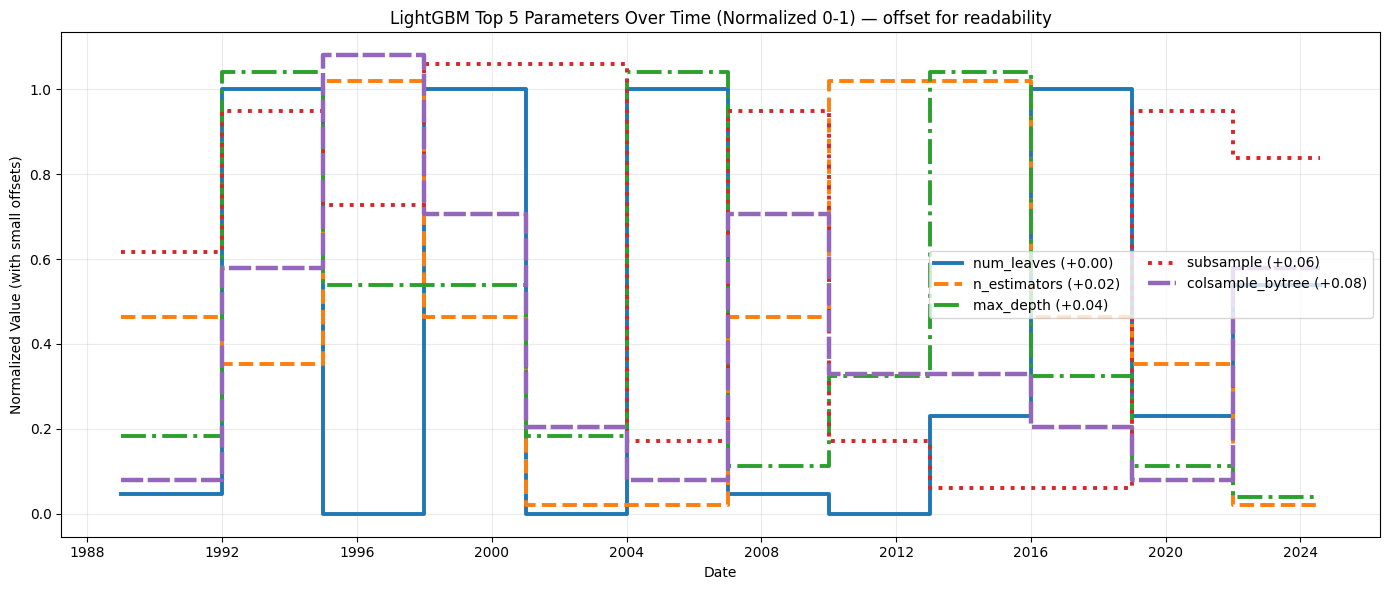

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

ph = pd.DataFrame(meta_lgbm["params_history"]).copy()
ph["cutoff_start"] = pd.to_datetime(ph["cutoff_start"])
ph["cutoff_end"] = ph["cutoff_start"] + pd.offsets.MonthBegin(1) * (ph["n_windows"] - 1)
ph = ph.sort_values("cutoff_start").reset_index(drop=True)

top5_params = ["num_leaves", "n_estimators", "max_depth", "subsample", "colsample_bytree"]
top5_params = [p for p in top5_params if p in ph.columns]

def build_step_series(hist_df, param):
    x = [hist_df.loc[0, "cutoff_start"]]
    y = [hist_df.loc[0, param]]
    for _, r in hist_df.iterrows():
        x += [r["cutoff_start"], r["cutoff_end"]]
        y += [r[param], r[param]]
    return x, y

plt.figure(figsize=(14, 6))

# style plus visible
linestyles = ["-", "--", "-.", ":", (0, (5, 1))]
linewidths = [2.8, 2.8, 2.8, 2.8, 3.2]

# petit décalage vertical par série
offsets = np.linspace(0.00, 0.08, len(top5_params))

for param, ls, lw, off in zip(top5_params, linestyles, linewidths, offsets):
    x, y = build_step_series(ph, param)
    y = np.array(y, dtype=float)

    y_norm = (y - y.min()) / (y.max() - y.min()) if y.max() != y.min() else y
    y_plot = np.clip(y_norm + off, 0, 1.08)  # clip pour rester visible

    plt.step(x, y_plot, where="post", linestyle=ls, linewidth=lw, label=f"{param} (+{off:.2f})")

plt.title("LightGBM Top 5 Parameters Over Time (Normalized 0-1) — offset for readability")
plt.xlabel("Date")
plt.ylabel("Normalized Value (with small offsets)")
plt.grid(True, alpha=0.25)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

# Importer Artefact de autres modèles depuis MLFLOW

In [16]:
import pandas as pd
import mlflow
from mlflow.tracking import MlflowClient

mlflow.set_tracking_uri("http://127.0.0.1:5000")
client = MlflowClient()

RUN_ID = "3368c351f6414b55a58a26b8d77947dd"

def load_artifact_csv(run_id: str, artifact_path: str, index_col=0, parse_dates=None) -> pd.DataFrame:
    local_path = client.download_artifacts(
        run_id=run_id,
        path=artifact_path,
        dst_path="tmp_mlflow_dl"
    )
    return pd.read_csv(local_path, index_col=index_col, parse_dates=parse_dates)

def ensure_month_start(df):
    df = df.copy()
    df.index = pd.to_datetime(df.index, errors="coerce")
    df = df[~df.index.isna()]
    df.index = df.index.to_period("M").to_timestamp(how="start")
    df = df[~df.index.duplicated(keep="last")]
    return df.sort_index()

# =====================================================
# 1) Tables
# =====================================================
mae_dm_pivot   = load_artifact_csv(RUN_ID, "tables/mae_dm_pivot.csv", index_col=0)
coverage_pivot = load_artifact_csv(RUN_ID, "tables/coverage_pivot.csv", index_col=0)
width_pivot    = load_artifact_csv(RUN_ID, "tables/width_pivot.csv", index_col=0)

# =====================================================
# 2) Tests
# =====================================================
coverage_mcnemar = load_artifact_csv(
    RUN_ID,
    "tests/coverage_mcnemar_ridge_vs_models.csv",
    index_col=0
)

width_paired = load_artifact_csv(
    RUN_ID,
    "tests/width_paired_ttest_ridge_vs_models.csv",
    index_col=0
)

# =====================================================
# 3) OOS Predictions (AR1 / ARp / LR / RIDGE)
# =====================================================
df_ar1 = load_artifact_csv(
    RUN_ID,
    "oos/oos_predictions_ar1.csv",
    index_col=0,
    parse_dates=[0]
)

df_arp = load_artifact_csv(
    RUN_ID,
    "oos/oos_predictions_arp_cv.csv",
    index_col=0,
    parse_dates=[0]
)

df_lr = load_artifact_csv(
    RUN_ID,
    "oos/oos_predictions_lr.csv",
    index_col=0,
    parse_dates=[0]
)

df_ridge = load_artifact_csv(
    RUN_ID,
    "oos/oos_predictions_ridge.csv",
    index_col=0,
    parse_dates=[0]
)

# Normalisation Month-Start (important pour tes utils)
df_ar1   = ensure_month_start(df_ar1)
df_arp   = ensure_month_start(df_arp)
df_lr    = ensure_month_start(df_lr)
df_ridge = ensure_month_start(df_ridge)

# =====================================================
# 4) Vérification
# =====================================================
print("=== MAE + DM Pivot ===")
display(mae_dm_pivot)

print("=== OOS RIDGE (head) ===")
display(df_ridge.head())

=== MAE + DM Pivot ===


,Ensemble,1990-1999,2000-2008,2008-2019,2020-fin
model,,,,,
AR1,0.8788 (0.149),0.5078 (0.109),0.5356 (0.266),0.8686 (0.357),2.0848 (0.199)
ARp,0.8779 (0.230),0.4951,0.5287 (0.300),0.8442 (0.543),2.1595 (0.196)
LR,0.8120 (0.600),0.5097 (0.825),0.4673 (0.377),0.7976 (0.712),1.8895 (0.980)
RIDGE,0.7985,0.4987 (0.958),0.4459,0.7839,1.8861


=== OOS RIDGE (head) ===


,y_true,y_hat,y_hat_p05,y_hat_p95
date,,,,
1990-01-01,0.0,-0.374110,-0.607142,-0.141079
1990-02-01,0.1,-0.415840,-1.277387,0.445707
1990-03-01,0.2,-0.424608,-1.467775,0.618558
1990-04-01,0.2,-0.334295,-1.268968,0.600377
1990-05-01,0.2,-0.069912,-0.794322,0.654498


In [17]:
import pandas as pd

# --- 1) Normaliser index Month-Start
def ms(df):
    d = df.copy()
    if "date" in d.columns:
        d["date"] = pd.to_datetime(d["date"], errors="coerce")
        d = d.dropna(subset=["date"]).set_index("date")
    d.index = pd.to_datetime(d.index, errors="coerce")
    d = d[~d.index.isna()].sort_index()
    d.index = d.index.to_period("M").to_timestamp(how="start")
    d = d[~d.index.duplicated(keep="last")]
    return d

df_ar1   = ms(df_ar1)
df_arp   = ms(df_arp)
df_lr    = ms(df_lr)
df_ridge = ms(df_ridge)

# --- 2) wide
all_idx = df_ridge.index.union(df_ar1.index).union(df_arp.index).union(df_lr.index)
wide = pd.DataFrame(index=all_idx)
wide.index.name = "date"

wide["true"]  = df_ridge["y_true"].reindex(all_idx)
wide["AR1"]   = df_ar1["y_hat"].reindex(all_idx)
wide["ARp"]   = df_arp["y_hat"].reindex(all_idx)
wide["LR"]    = df_lr["y_hat"].reindex(all_idx)
wide["RIDGE"] = df_ridge["y_hat"].reindex(all_idx)

wide = wide.reset_index()

# --- 3) Ajouter LGBM (si dispo)
lgbm = df_oos_lgbm.reset_index()
if "date" not in lgbm.columns:
    lgbm = lgbm.rename(columns={lgbm.columns[0]:"date"})
lgbm["date"] = pd.to_datetime(lgbm["date"], errors="coerce").dt.to_period("M").dt.to_timestamp(how="start")
lgbm = lgbm.rename(columns={"y_hat": "LGBM"})
wide = wide.merge(lgbm[["date","LGBM"]], on="date", how="left")

# --- 4) Tableau MAE + DM
segments = [
    ("1990-01-01", "1999-12-31", "1990-1999"),
    ("2000-01-01", "2008-12-31", "2000-2008"),
    ("2008-01-01", "2019-12-31", "2008-2019"),
    ("2020-01-01", None,         "2020-fin"),
]

table_pivot = make_mae_dm_pivot(
    wide=wide,
    segments=segments,
    methods=["AR1","ARp","LR","RIDGE","LGBM"],
    dm_lags=11,
    add_dm=True,
)

display(table_pivot)

period,Ensemble,1990-1999,2000-2008,2008-2019,2020-fin
model,,,,,
AR1,0.8670 (0.011),0.5078 (0.693),0.5356 (0.094),0.8686 (0.046),2.0848 (0.103)
ARp,0.8651 (0.027),0.4951 (0.819),0.5287 (0.132),0.8442 (0.093),2.1595 (0.115)
LR,0.8120 (0.063),0.5097 (0.350),0.4673 (0.198),0.7976 (0.005),1.8895 (0.740)
RIDGE,0.7985 (0.046),0.4987 (0.621),0.4459 (0.530),0.7839 (0.029),1.8861 (0.543)
LGBM,0.7372,0.4781,0.4171,0.6680,1.8185


# Métrique

In [19]:
import numpy as np
import pandas as pd

# ----------------------------
# 0) Périodes
# ----------------------------
periods = {
    "ALL":        (None, None),
    "1990_1999":  ("1990-01-01", "1999-12-31"),
    "2000_2008":  ("2000-01-01", "2008-12-31"),
    "2008_2019":  ("2008-01-01", "2019-12-31"),
    "2020_fin":   ("2020-01-01", None),
}

def ensure_dt_index(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()
    # accepte 'date' en colonne
    if "date" in d.columns:
        d["date"] = pd.to_datetime(d["date"], errors="coerce")
        d = d.dropna(subset=["date"]).set_index("date")
    d.index = pd.to_datetime(d.index, errors="coerce")
    d = d[~d.index.isna()].sort_index()
    return d

def coverage_95(sub: pd.DataFrame) -> float:
    need = ["y_true", "y_hat_p05", "y_hat_p95"]
    miss = [c for c in need if c not in sub.columns]
    if miss:
        return np.nan
    sub = sub.dropna(subset=need)
    if len(sub) == 0:
        return np.nan
    covered = (sub["y_true"] >= sub["y_hat_p05"]) & (sub["y_true"] <= sub["y_hat_p95"])
    return float(covered.mean())

def coverage_by_periods(df: pd.DataFrame) -> dict:
    d = ensure_dt_index(df)
    out = {}
    for label, (start, end) in periods.items():
        sub = d
        if start is not None:
            sub = sub[sub.index >= pd.Timestamp(start)]
        if end is not None:
            sub = sub[sub.index <= pd.Timestamp(end)]
        out[f"pi_coverage_95_{label}"] = coverage_95(sub)
    return out

# ----------------------------
# 1) Calcul coverage pour chaque modèle (à partir des df OOS)
# ----------------------------
# Remplace les variables par tes noms réels en mémoire
oos_map = {
    "AR1":   df_ar1,
    "ARp":   df_arp,
    "LR":    df_lr,
    "RIDGE": df_oos_ridge if "df_oos_ridge" in globals() else df_ridge,
    "LGBM":  df_oos_lgbm,
}

rows = []
for model, df in oos_map.items():
    cov = coverage_by_periods(df)
    cov["model"] = model
    rows.append(cov)

cov_df = pd.DataFrame(rows).set_index("model")

# ----------------------------
# 2) Tableau final Coverage (même format que MAE)
# ----------------------------
col_map = {
    "pi_coverage_95_ALL": "Ensemble",
    "pi_coverage_95_1990_1999": "1990-1999",
    "pi_coverage_95_2000_2008": "2000-2008",
    "pi_coverage_95_2008_2019": "2008-2019",
    "pi_coverage_95_2020_fin": "2020-fin",
}

coverage_table = cov_df.loc[:, list(col_map.keys())].rename(columns=col_map)

# ordre lignes
coverage_table = coverage_table.reindex(["AR1", "ARp", "LR", "RIDGE", "LGBM"])

coverage_table = coverage_table.round(3)
coverage_table.columns.name = "period"
coverage_table.index.name = "model"

display(coverage_table)

period,Ensemble,1990-1999,2000-2008,2008-2019,2020-fin
model,,,,,
AR1,0.735,0.742,0.685,0.736,0.691
ARp,0.757,0.817,0.694,0.771,0.706
LR,0.778,0.817,0.685,0.792,0.779
RIDGE,0.776,0.808,0.676,0.764,0.794
LGBM,0.769,0.808,0.694,0.736,0.765


In [21]:

# =========================================================
# 2) Fonction coverage binaire (clé du test)
# =========================================================
def covered_series(df):
    df = df.dropna(subset=["y_true", "y_hat_p05", "y_hat_p95"])
    covered = (
        (df["y_true"] >= df["y_hat_p05"]) &
        (df["y_true"] <= df["y_hat_p95"])
    ).astype(int)
    return covered

# =========================================================
# 3) Test McNemar (paired coverage test)
# =========================================================
def coverage_mcnemar_test(df_ridge, df_other, start=None, end=None):
    
    d1 = df_ridge.copy()
    d2 = df_other.copy()
    
    if start is not None:
        d1 = d1[d1.index >= pd.Timestamp(start)]
        d2 = d2[d2.index >= pd.Timestamp(start)]
    if end is not None:
        d1 = d1[d1.index <= pd.Timestamp(end)]
        d2 = d2[d2.index <= pd.Timestamp(end)]
    
    # Alignement temporel (CRUCIAL)
    common_idx = d1.index.intersection(d2.index)
    d1 = d1.loc[common_idx]
    d2 = d2.loc[common_idx]
    
    c1 = covered_series(d1)
    c2 = covered_series(d2)
    
    common_idx = c1.index.intersection(c2.index)
    c1 = c1.loc[common_idx]
    c2 = c2.loc[common_idx]
    
    if len(c1) < 30:
        return "NaN", np.nan, 0
    
    # Table de contingence McNemar
    both_correct = np.sum((c1 == 1) & (c2 == 1))
    ridge_only   = np.sum((c1 == 1) & (c2 == 0))
    other_only   = np.sum((c1 == 0) & (c2 == 1))
    both_wrong   = np.sum((c1 == 0) & (c2 == 0))
    
    table = [[both_correct, ridge_only],
             [other_only, both_wrong]]
    
    result = mcnemar(table, exact=False, correction=True)
    
    cov_ridge = c1.mean()
    cov_other = c2.mean()
    diff = cov_ridge - cov_other
    
    return diff, result.pvalue, len(c1)

# =========================================================
# 4) Segments macro (comme ton pipeline)
# =========================================================
periods = {
    "ALL":        (None, None),
    "1990-1999":  ("1990-01-01", "1999-12-31"),
    "2000-2008":  ("2000-01-01", "2008-12-31"),
    "2008-2019":  ("2008-01-01", "2019-12-31"),
    "2020-fin":   ("2020-01-01", None),
}

# =========================================================
# 5) Tableau de significativité Coverage (comme ton DM)
# =========================================================
comparisons = {
    "RIDGE vs AR1": df_ar1,
    "RIDGE vs ARp": df_arp,
    "RIDGE vs LR":  df_lr,
}

results = {}

for period_name, (start, end) in periods.items():
    row = {}
    
    for comp_name, df_other in comparisons.items():
        diff, p_val, n = coverage_mcnemar_test(
            df_ridge, df_other, start, end
        )
        
        if np.isnan(p_val):
            cell = "NaN"
        else:
            cell = f"Δcov={diff:.3f} (p={p_val:.3f})"
        
        row[comp_name] = cell
    
    results[period_name] = row

coverage_significance_pivot = pd.DataFrame(results).T
coverage_significance_pivot.index.name = "period"

display(coverage_significance_pivot)


,RIDGE vs AR1,RIDGE vs ARp,RIDGE vs LR
period,,,
ALL,Δcov=0.040 (p=0.051),Δcov=0.002 (p=1.000),Δcov=-0.002 (p=1.000)
1990-1999,Δcov=0.067 (p=0.170),Δcov=-0.008 (p=1.000),Δcov=-0.008 (p=1.000)
2000-2008,Δcov=-0.009 (p=1.000),Δcov=-0.019 (p=0.803),Δcov=-0.009 (p=1.000)
2008-2019,Δcov=0.028 (p=0.522),Δcov=-0.007 (p=1.000),Δcov=-0.028 (p=0.386)
2020-fin,Δcov=0.103 (p=0.023),Δcov=0.088 (p=0.041),Δcov=0.015 (p=1.000)


# Width

In [22]:
import numpy as np
import pandas as pd

# =========================================================
# 0) Segments
# =========================================================
periods = {
    "ALL":        (None, None),
    "1990_1999":  ("1990-01-01", "1999-12-31"),
    "2000_2008":  ("2000-01-01", "2008-12-31"),
    "2008_2019":  ("2008-01-01", "2019-12-31"),
    "2020_fin":   ("2020-01-01", None),
}

def ensure_dt_index(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()
    if "date" in d.columns:
        d["date"] = pd.to_datetime(d["date"], errors="coerce")
        d = d.dropna(subset=["date"]).set_index("date")
    d.index = pd.to_datetime(d.index, errors="coerce")
    d = d[~d.index.isna()].sort_index()
    # ✅ Month-start pour alignement segments
    d.index = d.index.to_period("M").to_timestamp(how="start")
    d = d[~d.index.duplicated(keep="last")]
    return d

def width_stats_by_periods(df: pd.DataFrame) -> dict:
    d = ensure_dt_index(df)

    required_cols = {"y_hat_p05", "y_hat_p95"}
    if not required_cols.issubset(set(d.columns)):
        # pas d'intervalle -> NaN
        out = {}
        for label in periods.keys():
            out[f"pi_avg_width_{label}"] = np.nan
            out[f"pi_median_width_{label}"] = np.nan
        return out

    out = {}
    for label, (start, end) in periods.items():
        sub = d
        if start is not None:
            s = pd.Timestamp(start).to_period("M").to_timestamp(how="start")
            sub = sub[sub.index >= s]
        if end is not None:
            e = pd.Timestamp(end).to_period("M").to_timestamp(how="start")
            sub = sub[sub.index <= e]

        sub = sub.dropna(subset=["y_hat_p05", "y_hat_p95"])
        if len(sub) == 0:
            out[f"pi_avg_width_{label}"] = np.nan
            out[f"pi_median_width_{label}"] = np.nan
            continue

        width = (sub["y_hat_p95"] - sub["y_hat_p05"]).astype(float)
        out[f"pi_avg_width_{label}"] = float(width.mean())
        out[f"pi_median_width_{label}"] = float(width.median())

    return out

# =========================================================
# 1) DFs OOS (remplace par tes noms réels si besoin)
# =========================================================
oos_map = {
    "AR1":   df_ar1,
    "ARp":   df_arp,
    "LR":    df_lr,
    "RIDGE": df_oos_ridge if "df_oos_ridge" in globals() else df_ridge,
    "LGBM":  df_oos_lgbm,
}

# =========================================================
# 2) Calcul width pour tous les modèles
# =========================================================
rows = []
for model, df in oos_map.items():
    d = width_stats_by_periods(df)
    d["model"] = model
    rows.append(d)

width_stats_df = pd.DataFrame(rows).set_index("model")

# =========================================================
# 3) Tableau final WIDTH (avg width) même format que MAE
# =========================================================
col_map = {
    "pi_avg_width_ALL": "Ensemble",
    "pi_avg_width_1990_1999": "1990-1999",
    "pi_avg_width_2000_2008": "2000-2008",
    "pi_avg_width_2008_2019": "2008-2019",
    "pi_avg_width_2020_fin": "2020-fin",
}

width_table = (
    width_stats_df.loc[:, list(col_map.keys())]
    .rename(columns=col_map)
    .reindex(["AR1", "ARp", "LR", "RIDGE", "LGBM"])
    .round(3)
)

width_table.columns.name = "period"
width_table.index.name = "model"

display(width_table)

# (optionnel) Median width table si tu veux aussi
median_col_map = {k.replace("pi_avg_width_", "pi_median_width_"): v for k, v in col_map.items()}
median_width_table = (
    width_stats_df.loc[:, list(median_col_map.keys())]
    .rename(columns=median_col_map)
    .reindex(["AR1", "ARp", "LR", "RIDGE", "LGBM"])
    .round(3)
)
median_width_table.columns.name = "period"
median_width_table.index.name = "model"

# display(median_width_table)

period,Ensemble,1990-1999,2000-2008,2008-2019,2020-fin
model,,,,,
AR1,3.212,1.640,1.511,2.770,8.661
ARp,3.279,1.764,1.570,2.904,9.136
LR,2.841,1.725,1.588,2.617,6.950
RIDGE,2.701,1.620,1.429,2.528,6.642
LGBM,2.584,1.627,1.237,2.326,6.598


In [25]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_rel

# ---------------------------
# 0) Normalisation Month-Start (CRUCIAL)
# ---------------------------
def ms_index(df):
    d = df.copy()
    if "date" in d.columns:
        d["date"] = pd.to_datetime(d["date"], errors="coerce")
        d = d.dropna(subset=["date"]).set_index("date")
    d.index = pd.to_datetime(d.index, errors="coerce")
    d = d[~d.index.isna()].sort_index()
    d.index = d.index.to_period("M").to_timestamp(how="start")
    d = d[~d.index.duplicated(keep="last")]
    return d

df_ar1   = ms_index(df_ar1)
df_arp   = ms_index(df_arp)
df_lr    = ms_index(df_lr)
df_ridge = ms_index(df_oos_ridge if "df_oos_ridge" in globals() else df_ridge)
df_lgbm  = ms_index(df_oos_lgbm if "df_oos_lgbm" in globals() else df_lgbm)

# ---------------------------
# 1) Width
# ---------------------------
def compute_width(df):
    return (df["y_hat_p95"] - df["y_hat_p05"]).astype(float)

# ---------------------------
# 2) Paired t-test (RIDGE vs OTHER)
# ---------------------------
def paired_width_test(df_ridge, df_other, start=None, end=None):
    d1 = df_ridge.copy()
    d2 = df_other.copy()

    if start is not None:
        s = pd.Timestamp(start).to_period("M").to_timestamp(how="start")
        d1 = d1[d1.index >= s]
        d2 = d2[d2.index >= s]
    if end is not None:
        e = pd.Timestamp(end).to_period("M").to_timestamp(how="start")
        d1 = d1[d1.index <= e]
        d2 = d2[d2.index <= e]

    # align
    common_idx = d1.index.intersection(d2.index)
    d1 = d1.loc[common_idx].dropna(subset=["y_hat_p05", "y_hat_p95"])
    d2 = d2.loc[common_idx].dropna(subset=["y_hat_p05", "y_hat_p95"])

    common_idx = d1.index.intersection(d2.index)
    if len(common_idx) < 30:
        return np.nan, np.nan, np.nan, int(len(common_idx))

    w1 = compute_width(d1.loc[common_idx])
    w2 = compute_width(d2.loc[common_idx])

    t_stat, p_val = ttest_rel(w1, w2, nan_policy="omit")
    mean_diff = float((w1 - w2).mean())  # <0 => RIDGE plus étroit
    return float(t_stat), float(p_val), mean_diff, int(len(common_idx))

# ---------------------------
# 3) Segments
# ---------------------------
periods = {
    "ALL":        (None, None),
    "1990-1999":  ("1990-01-01", "1999-12-31"),
    "2000-2008":  ("2000-01-01", "2008-12-31"),
    "2008-2019":  ("2008-01-01", "2019-12-31"),
    "2020-fin":   ("2020-01-01", None),
}

comparisons = {
    "RIDGE vs AR1":  df_ar1,
    "RIDGE vs ARp":  df_arp,
    "RIDGE vs LR":   df_lr,
    "RIDGE vs LGBM": df_lgbm,
}

# ---------------------------
# 4) Pivot significativité
# ---------------------------
results = {}
for period_name, (start, end) in periods.items():
    row = {}
    for comp_name, df_other in comparisons.items():
        t_stat, p_val, mean_diff, n = paired_width_test(df_ridge, df_other, start, end)
        if np.isnan(p_val):
            cell = "NaN"
        else:
            cell = f"Δ={mean_diff:.3f} (p={p_val:.3f}, n={n})"
        row[comp_name] = cell
    results[period_name] = row

width_significance_pivot = pd.DataFrame(results).T
width_significance_pivot.index.name = "period"

display(width_significance_pivot)

,RIDGE vs AR1,RIDGE vs ARp,RIDGE vs LR,RIDGE vs LGBM
period,,,,
ALL,"Δ=-0.426 (p=0.000, n=428)","Δ=-0.593 (p=0.000, n=428)","Δ=-0.140 (p=0.007, n=428)","Δ=0.116 (p=0.000, n=428)"
1990-1999,"Δ=-0.021 (p=0.731, n=120)","Δ=-0.144 (p=0.012, n=120)","Δ=-0.105 (p=0.000, n=120)","Δ=-0.007 (p=0.886, n=120)"
2000-2008,"Δ=-0.082 (p=0.285, n=108)","Δ=-0.141 (p=0.044, n=108)","Δ=-0.158 (p=0.000, n=108)","Δ=0.192 (p=0.000, n=108)"
2008-2019,"Δ=-0.241 (p=0.030, n=144)","Δ=-0.376 (p=0.000, n=144)","Δ=-0.088 (p=0.008, n=144)","Δ=0.202 (p=0.000, n=144)"
2020-fin,"Δ=-2.018 (p=0.000, n=68)","Δ=-2.493 (p=0.000, n=68)","Δ=-0.307 (p=0.331, n=68)","Δ=0.044 (p=0.482, n=68)"


# Graphique

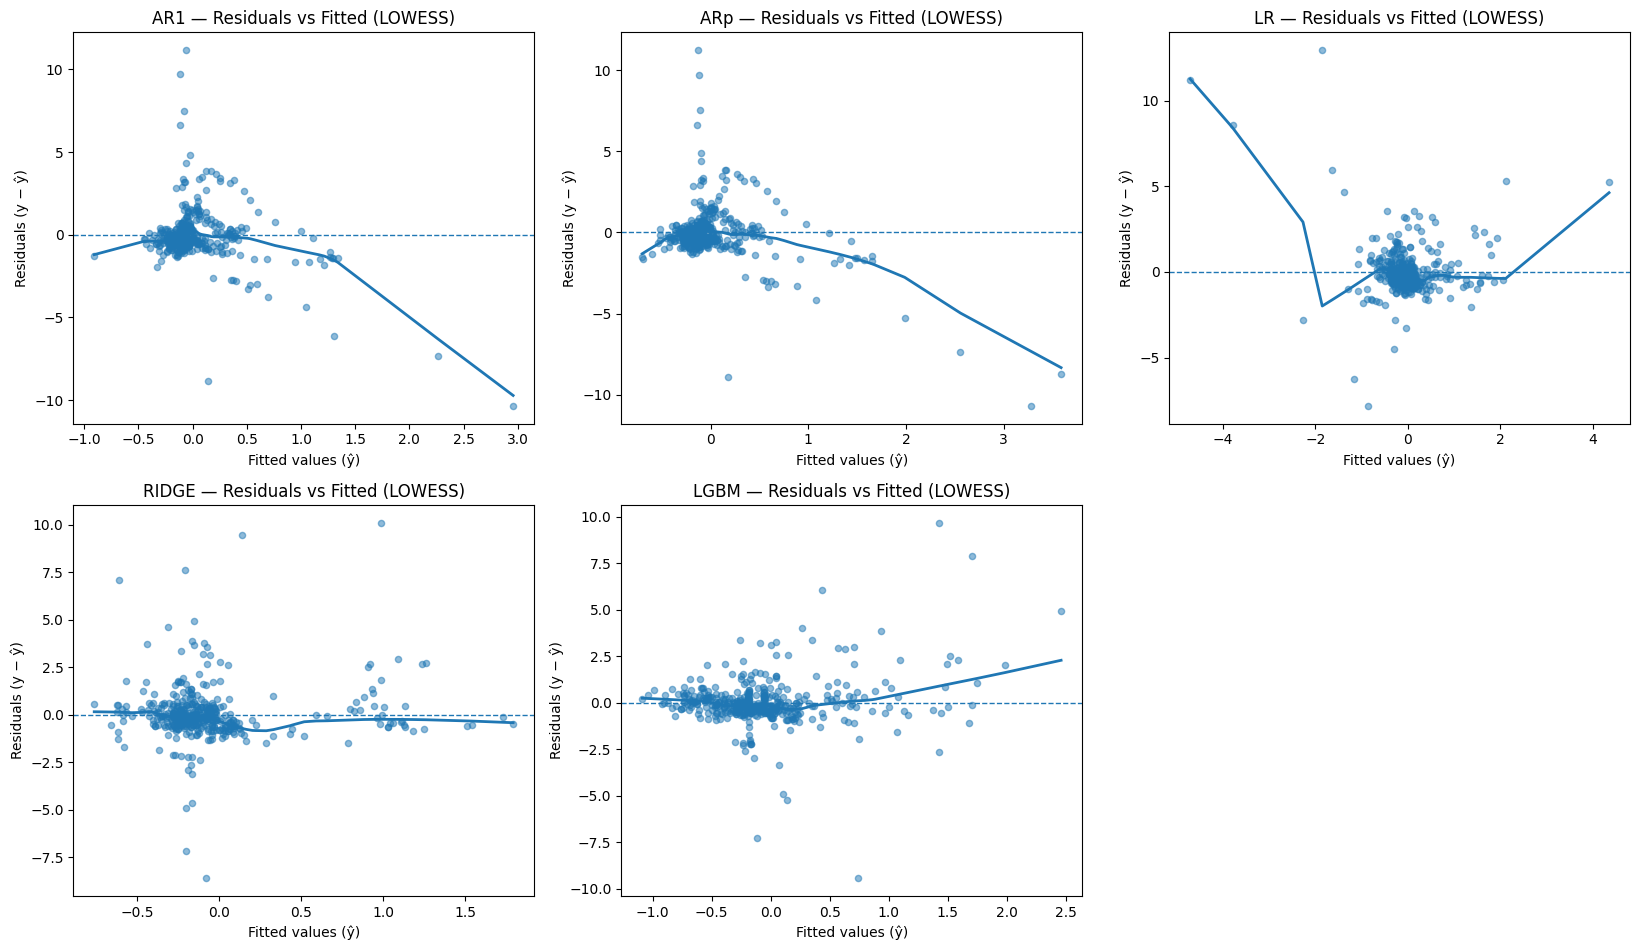

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess
import math

# =========================================================
# 1) Vérif wide + nettoyage
# =========================================================
if "wide" not in globals():
    raise ValueError("wide n'est pas défini. Recrée-le d'abord.")

w = wide.copy()
w["date"] = pd.to_datetime(w["date"], errors="coerce")
w = w.dropna(subset=["date", "true"]).sort_values("date")
w = w[w["date"] >= "1990-01-01"]

# =========================================================
# 2) Choisir modèles automatiquement (ou fixe)
# =========================================================
candidate_models = ["AR1", "ARp", "LR", "RIDGE", "LGBM"]
models = [m for m in candidate_models if m in w.columns]

if len(models) == 0:
    raise ValueError("Aucun modèle trouvé dans wide (AR1/ARp/LR/RIDGE/LGBM).")

# =========================================================
# 3) Résidus + plots residuals vs fitted + LOWESS
# =========================================================
n = len(models)
ncols = 2 if n <= 4 else 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4.8 * nrows))
axes = np.array(axes).reshape(-1)

for ax, m in zip(axes, models):
    sub = w.dropna(subset=[m]).copy()
    sub["resid"] = sub["true"] - sub[m]
    sub = sub.dropna(subset=["resid"])

    x = sub[m].to_numpy()
    y = sub["resid"].to_numpy()

    # scatter
    ax.scatter(x, y, alpha=0.5, s=20)

    # LOWESS
    if len(sub) >= 30:
        sm = lowess(y, x, frac=0.25, return_sorted=True)
        ax.plot(sm[:, 0], sm[:, 1], linewidth=2)

    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_title(f"{m} — Residuals vs Fitted (LOWESS)")
    ax.set_xlabel("Fitted values (ŷ)")
    ax.set_ylabel("Residuals (y − ŷ)")

# cacher axes vides
for ax in axes[len(models):]:
    ax.axis("off")

plt.tight_layout()

plt.show()

# Analyons

## AR1

### A quelles dates AR1 et ARp ou-estime les grande chômage ?

In [48]:
m = "AR1"   # ou "ARp"

sub = w.dropna(subset=[m, "true"]).copy()
sub["resid"] = sub["true"] - sub[m]

mask = (sub["resid"] > 4) & (sub[m] < 0.5)

hits = sub.loc[mask, ["date", "true", m, "resid"]].sort_values("resid")

print(hits)
print("\nNb de points:", len(hits))

          date  true       AR1      resid
681 2020-09-01   4.3 -0.061764   4.361764
680 2020-08-01   4.8 -0.025650   4.825650
679 2020-07-01   6.5 -0.116439   6.616439
678 2020-06-01   7.4 -0.076515   7.476515
677 2020-05-01   9.6 -0.114730   9.714730
676 2020-04-01  11.1 -0.062218  11.162218

Nb de points: 6


### Quand AR uretime une grande valeur de chômage? 

In [50]:
m = "AR1"   # ou "ARp"

sub = w.dropna(subset=[m, "true"]).copy()
sub["resid"] = sub["true"] - sub[m]

mask = (sub["resid"] < -5) & (sub[m] > 1)

hits = sub.loc[mask, ["date", "true", m, "resid"]].sort_values("resid")

print(hits)
print("\nNb de points:", len(hits))

          date  true       AR1      resid
689 2021-05-01  -7.4  2.957479 -10.357479
690 2021-06-01  -5.1  2.264549  -7.364549
691 2021-07-01  -4.8  1.301029  -6.101029

Nb de points: 3


Le modèle AR sous-estime donc l'avènement de la crise Covid-19. Il n'arrive pas à bien capter la décroissance après Crise que tardivement. 

Il et donc toujour en retard. 

# LR

### Quand et-ce que LR ous-estime une valeur faible ? 

In [51]:
m = "LR"

sub = w.dropna(subset=[m, "true"]).copy()
sub["resid"] = sub["true"] - sub[m]

In [58]:
m = "LR"   # change: "AR1", "ARp", "RIDGE", "LGBM"

sub = w.dropna(subset=[m, "true"]).copy()
sub["resid"] = sub["true"] - sub[m]

hits = (
    sub[(sub["resid"] < -5) & (sub[m] < 0)]
    .sort_values("resid", ascending=False)[["date", "true", m, "resid"]]
)

print(hits)
print("\nNb de points:", len(hits))

          date  true        LR     resid
689 2021-05-01  -7.4 -1.155543 -6.244457
688 2021-04-01  -8.7 -0.872004 -7.827996

Nb de points: 2


# LR surestime de valeur faible

In [62]:
m = "LR"   # change: "AR1", "ARp", "RIDGE", "LGBM"

sub = w.dropna(subset=[m, "true"]).copy()
sub["resid"] = sub["true"] - sub[m]

hits = (
    sub[(sub["resid"] > 5) & (sub[m] < 0)]
    .sort_values("resid", ascending=False)[["date", "true", m, "resid"]]
)

print(hits)
print("\nNb de points:", len(hits))

          date  true        LR      resid
676 2020-04-01  11.1 -1.851504  12.951504
679 2020-07-01   6.5 -4.707476  11.207476
680 2020-08-01   4.8 -3.788333   8.588333
681 2020-09-01   4.3 -1.644703   5.944703

Nb de points: 4


### Quand est-ce que LR sous-estime une valeur élevée? 

In [54]:
m = "LR"   # change: "AR1", "ARp", "RIDGE", "LGBM"

sub = w.dropna(subset=[m, "true"]).copy()
sub["resid"] = sub["true"] - sub[m]

hits = (
    sub[(sub["resid"] > 5) & (sub[m] > 0)]
    .sort_values("resid", ascending=False)[["date", "true", m, "resid"]]
)

print(hits)
print("\nNb de points:", len(hits))

          date  true        LR     resid
678 2020-06-01   7.4  2.113067  5.286933
677 2020-05-01   9.6  4.349088  5.250912

Nb de points: 2


Régression sous-estime vraiment le Covid-19. Mais il a amélioré pas mal de point : 
- il n'est plus en retards ; 
- Le nombre de point uretimé pot covid a diminué ; 
- Sa surestimation de post-covid a diminué par rapport à AR ; 
Ce ont de point centraux en Covid-19 qu'il a apporté. 

# Ridge

In [60]:
m = "RIDGE"

sub = w.dropna(subset=[m, "true"]).copy()
sub["resid"] = sub["true"] - sub[m]

hits = (
    sub[(sub["resid"] < -5) & (sub[m] < 0)]
    .sort_values("resid", ascending=False)
    [["date", "true", m, "resid"]]
)

print(hits)
print("\nNb de points:", len(hits))

          date  true     RIDGE     resid
689 2021-05-01  -7.4 -0.198934 -7.201066
688 2021-04-01  -8.7 -0.080223 -8.619777

Nb de points: 2


Il a réuii à hier d'un point l'écart de réid sur chaque point par rapport à LR. 

il uretime moin que la Régreion linéaire ur de préviion faible. 

ou-etime avec valeur haue plu que la régreion linéaire

In [64]:
m = "RIDGE"

sub = w.dropna(subset=[m, "true"]).copy()
sub["resid"] = sub["true"] - sub[m]

hits = (
    sub[(sub["resid"] > 5) & (sub[m] < 0)]
    .sort_values("resid", ascending=False)
    [["date", "true", m, "resid"]]
)

print(hits)
print("\nNb de points:", len(hits))

          date  true     RIDGE     resid
678 2020-06-01   7.4 -0.208887  7.608887
679 2020-07-01   6.5 -0.606593  7.106593

Nb de points: 2


il uretime moin que la Régreion linéaire ur de préviion faible. 

In [57]:
hits_over = (
    sub[(sub["resid"] < -5) & (sub[m] < 0.5)]
    .sort_values("resid")
    [["date", "true", m, "resid"]]
)

print(hits_over)
print("\nNb de points:", len(hits_over))

          date  true     RIDGE     resid
688 2021-04-01  -8.7 -0.080223 -8.619777
689 2021-05-01  -7.4 -0.198934 -7.201066

Nb de points: 2


In [65]:
hits_over = (
    sub[(sub["resid"] > 5) & (sub[m] > 0)]
    .sort_values("resid")
    [["date", "true", m, "resid"]]
)

print(hits_over)
print("\nNb de points:", len(hits_over))

          date  true     RIDGE      resid
677 2020-05-01   9.6  0.142457   9.457543
676 2020-04-01  11.1  0.984342  10.115658

Nb de points: 2


ou-etime avec valeur haue plu que la régreion linéaire

## LGBM

### Sous-estimation forte

In [66]:
m = "LGBM"

sub = w.dropna(subset=[m, "true"]).copy()
sub["resid"] = sub["true"] - sub[m]

hits_under = (
    sub[(sub["resid"] > 5) & (sub[m] < 0)]
    .sort_values("resid", ascending=False)
    [["date", "true", m, "resid"]]
)

print("=== LGBM : Sous-estimation (resid > 5 & fitted < 0) ===")
print(hits_under)
print("\nNb de points:", len(hits_under))

=== LGBM : Sous-estimation (resid > 5 & fitted < 0) ===
Empty DataFrame
Columns: [date, true, LGBM, resid]
Index: []

Nb de points: 0


### Surestimation forte (zone basse)

In [67]:
hits_over_low = (
    sub[(sub["resid"] < -5) & (sub[m] < 0.5)]
    .sort_values("resid")
    [["date", "true", m, "resid"]]
)

print("\n=== LGBM : Surestimation basse (resid < -5 & fitted < 0.5) ===")
print(hits_over_low)
print("\nNb de points:", len(hits_over_low))


=== LGBM : Surestimation basse (resid < -5 & fitted < 0.5) ===
          date  true      LGBM     resid
689 2021-05-01  -7.4 -0.114258 -7.285742
690 2021-06-01  -5.1  0.134226 -5.234226

Nb de points: 2


### Surestimation forte (zone haute)

In [69]:
hits_over_high = (
    sub[(sub["resid"] < -5) & (sub[m] > 0)]
    .sort_values("resid")
    [["date", "true", m, "resid"]]
)

print("\n=== LGBM : Surestimation haute (resid < -5 & fitted > 1) ===")
print(hits_over_high)
print("\nNb de points:", len(hits_over_high))


=== LGBM : Surestimation haute (resid < -5 & fitted > 1) ===
          date  true      LGBM     resid
688 2021-04-01  -8.7  0.737134 -9.437134
690 2021-06-01  -5.1  0.134226 -5.234226

Nb de points: 2


In [76]:
records = []

for m in models:
    if m in w.columns:
        sub = w.dropna(subset=[m, "true"]).copy()
        sub["resid"] = sub["true"] - sub[m]

        rules = {
            "fit<0.5 & resid>5": (sub[m] < 0.5) & (sub["resid"] > 5),
            "fit<0.5 & resid<-5": (sub[m] < 0.5) & (sub["resid"] < -5),
            "fit>0.5 & resid<-5": (sub[m] > 0.5) & (sub["resid"] < -5),
            "fit>0.5 & resid>5": (sub[m] > 0.5) & (sub["resid"] > 5),
        }

        for rule_name, mask in rules.items():
            for d in sub.loc[mask, "date"]:
                records.append({
                    "Model": m,
                    "Rule": rule_name,
                    "Date": d.strftime("%Y-%m-%d")
                })

long_table = pd.DataFrame(records)
print(long_table)

    Model                Rule        Date
0     AR1   fit<0.5 & resid>5  2020-04-01
1     AR1   fit<0.5 & resid>5  2020-05-01
2     AR1   fit<0.5 & resid>5  2020-06-01
3     AR1   fit<0.5 & resid>5  2020-07-01
4     AR1  fit<0.5 & resid<-5  2021-04-01
5     AR1  fit>0.5 & resid<-5  2021-05-01
6     AR1  fit>0.5 & resid<-5  2021-06-01
7     AR1  fit>0.5 & resid<-5  2021-07-01
8     ARp   fit<0.5 & resid>5  2020-04-01
9     ARp   fit<0.5 & resid>5  2020-05-01
10    ARp   fit<0.5 & resid>5  2020-06-01
11    ARp   fit<0.5 & resid>5  2020-07-01
12    ARp  fit<0.5 & resid<-5  2021-04-01
13    ARp  fit>0.5 & resid<-5  2021-05-01
14    ARp  fit>0.5 & resid<-5  2021-06-01
15    ARp  fit>0.5 & resid<-5  2021-07-01
16    ARp  fit>0.5 & resid<-5  2021-08-01
17     LR   fit<0.5 & resid>5  2020-04-01
18     LR   fit<0.5 & resid>5  2020-07-01
19     LR   fit<0.5 & resid>5  2020-08-01
20     LR   fit<0.5 & resid>5  2020-09-01
21     LR  fit<0.5 & resid<-5  2021-04-01
22     LR  fit<0.5 & resid<-5  202

# Analyse

### Combien d’erreurs extrêmes par modèle ?

In [77]:
errors_by_model = (
    long_table.groupby("Model")
    .size()
    .reset_index(name="Total_extreme_errors")
    .sort_values("Total_extreme_errors", ascending=False)
)

print(errors_by_model)

   Model  Total_extreme_errors
1    ARp                     9
0    AR1                     8
3     LR                     8
2   LGBM                     6
4  RIDGE                     6


ARp (9) est le plus instable, suivi de AR1 et LR (8).
RIDGE et LGBM (6) sont les plus robustes.

Les modèles autorégressifs souffrent davantage en période de rupture, tandis que la régularisation (RIDGE) et le boosting (LGBM) offrent une meilleure stabilité face aux chocs.

## Répartition par type d’erreur (par modèle)

In [78]:
errors_by_rule = (
    long_table.groupby(["Model", "Rule"])
    .size()
    .unstack(fill_value=0)
)

print(errors_by_rule)

Rule   fit<0.5 & resid<-5  fit<0.5 & resid>5  fit>0.5 & resid<-5  \
Model                                                              
AR1                     1                  4                   3   
ARp                     1                  4                   4   
LGBM                    2                  1                   1   
LR                      2                  4                   0   
RIDGE                   2                  3                   0   

Rule   fit>0.5 & resid>5  
Model                     
AR1                    0  
ARp                    0  
LGBM                   2  
LR                     2  
RIDGE                  1  


# Quelles dates reviennent le plus ?

In [79]:
errors_by_date = (
    long_table.groupby("Date")
    .size()
    .reset_index(name="Nb_models_touchés")
    .sort_values("Nb_models_touchés", ascending=False)
)

print(errors_by_date.head(15))

          Date  Nb_models_touchés
0   2020-04-01                  5
1   2020-05-01                  5
3   2020-07-01                  5
7   2021-05-01                  5
6   2021-04-01                  5
2   2020-06-01                  4
8   2021-06-01                  3
9   2021-07-01                  2
4   2020-08-01                  1
5   2020-09-01                  1
10  2021-08-01                  1


### Quelles dates sont communes à plusieurs modèles ?

In [81]:
date_model_matrix = (
    long_table.groupby(["Date", "Model"])
    .size()
    .unstack(fill_value=0)
)

print(date_model_matrix)

Model       AR1  ARp  LGBM  LR  RIDGE
Date                                 
2020-04-01    1    1     1   1      1
2020-05-01    1    1     1   1      1
2020-06-01    1    1     0   1      1
2020-07-01    1    1     1   1      1
2020-08-01    0    0     0   1      0
2020-09-01    0    0     0   1      0
2021-04-01    1    1     1   1      1
2021-05-01    1    1     1   1      1
2021-06-01    1    1     1   0      0
2021-07-01    1    1     0   0      0
2021-08-01    0    1     0   0      0


## Comment

AR1 / ARp : erreurs surtout aux extrêmes → ils sont en retard pour capter la crise et dè qu'il captent, il prolongent trop les régimes. Il n'ont pa réui à capter la décroissance rapide du chômage. 

LR : Régression sous-estime vraiment le Covid-19. Mais il a amélioré pas mal de point : 
- il n'est plus en retards ; 
- Le nombre de point uretimé pot covid a diminué ; 
- Sa surestimation de post-covid a diminué par rapport à AR ; 
Malgré celà, il et instable et présent dans toutes les erreurs extrême. 

RIDGE : C'et globalement trè fort. Il a réuii à hier d'un point l'écart de réid sur chaque point par rapport à LR. il uretime moin que la Régreion linéaire ur de préviion faible. on inconvénient c'et qu'il ou-etime avec valeur haue plu que la régreion linéaire

LGBM : globalement robuste, mais rate certains pics élevés.

En bref : les modèles autorégressifs sont les plus fragiles ; RIDGE et LightGBM ont table en haute volatilité.

👉 C’est exactement le choc COVID.

En avril 2020, le taux de chômage US passe brutalement à 11.1% (pic historique post-WW2), alors que ton LGBM prédit ≈ 1.42 → résidu ≈ +9.67.

Même logique pour mai et juillet.

In [30]:
from utilsforecast.plotting import plot_series
import pandas as pd
import re

def _prep_oos_for_plot(df_oos, model_name: str, unique_id: str = "UNRATE"):
    d = df_oos.copy()

    # index -> datetime
    d.index = pd.to_datetime(d.index, errors="coerce")
    d = d[~d.index.isna()].sort_index()

    d = d.reset_index().rename(columns={d.index.name or "index": "ds"})

    # Observations
    df_obs = (
        d.rename(columns={"y_true": "y"})
         .assign(unique_id=unique_id)[["unique_id", "ds", "y"]]
    )

    # Forecast + PI
    df_fcst = (
        d.rename(columns={
            "y_hat": model_name,
            "y_hat_p05": f"{model_name}-lo-95",
            "y_hat_p95": f"{model_name}-hi-95",
        })
        .assign(unique_id=unique_id)[[
            "unique_id", "ds",
            model_name, f"{model_name}-lo-95", f"{model_name}-hi-95"
        ]]
    )

    return df_obs, df_fcst


# ============================================================
# 1) UTILISE TES VARIABLES EXISTANTES
# ============================================================
df_obs_ar1,  df_fcst_ar1  = _prep_oos_for_plot(df_ar1,   "AR1")
df_obs_arp,  df_fcst_arp  = _prep_oos_for_plot(df_arp,   "ARp")
df_obs_lr,   df_fcst_lr   = _prep_oos_for_plot(df_lr,    "LR")
df_obs_rdg,  df_fcst_rdg  = _prep_oos_for_plot(df_ridge, "RIDGE")
df_obs_lgbm, df_fcst_lgbm = _prep_oos_for_plot(df_lgbm,  "LGBM")

# ============================================================
# 2) Merge forecasts
# ============================================================
df_fcst = (
    df_fcst_ar1
    .merge(df_fcst_arp,  on=["unique_id", "ds"], how="inner")
    .merge(df_fcst_lr,   on=["unique_id", "ds"], how="inner")
    .merge(df_fcst_rdg,  on=["unique_id", "ds"], how="inner")
    .merge(df_fcst_lgbm, on=["unique_id", "ds"], how="inner")
)

df_obs = df_obs_ar1[df_obs_ar1["ds"].isin(df_fcst["ds"])].copy()

# ============================================================
# 3) Plot
# ============================================================
fig = plot_series(
    df=df_obs,
    forecasts_df=df_fcst,
    level=[95],
    engine="plotly",
).update_layout(height=520)

# ============================================================
# 4) Renommer légendes
# ============================================================
for trace in fig.data:
    name = trace.name or ""
    lname = name.lower()

    if name == "y":
        trace.name = "Unemployment rate (%)"
    elif name == "AR1":
        trace.name = "AutoRegressive AR(1)"
    elif name == "ARp":
        trace.name = "AutoRegressive AR(p)"
    elif name == "LR":
        trace.name = "Linear Regression"
    elif name == "RIDGE":
        trace.name = "Ridge Regression"
    elif name == "LGBM":
        trace.name = "LightGBM"
    elif "level_95" in lname:
        trace.name = f"{name.split('-')[0]} 95% Prediction Interval"

fig.show()